# Proyek Analisis Data: [PRSA_Data_Aotizhongxin_20130301-20170228]
- **Nama:** [Gamael Marcel]
- **Email:** [gamaelmarcel@gmail.com]
- **ID Dicoding:** [stelleguy]

## Menentukan Pertanyaan Bisnis

- Bagaimana kualitas udara di Stasiun Dingling di tahun 2016?
- Bagaimana suhu dan tekanan angin di Stasiun Dingling di tahun 2016?
- Bagaimana kualitas udara seperti titik embun, curah hujan, dan kecepatan angin di Stasiun Dingling di tahun 2016?
- Ke mana arah mata angin tersering di Stasiun Dingling di tahun 2016?
- Bagaimana hubungan antara suhu dengan tekanan angin di Stasiun Dingling?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Penjelasan tahapan:
- Dilakukan pengambilan raw database dari github untuk analisis cuaca di stasiun Dingling, China.

In [ ]:
ding_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/refs/heads/master/PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv")
ding_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


**Insight:**
- Pengukuran kualitas udara, paramaeter suhu, dan tekanan udara dilakukan setiap satu jam dimulai dari tanggal 1 Maret 2013.
- Terdapat beberapa variabel polutan udara untuk mengukur kualitas udara yang juga dipakai oleh BMKG seperti PM2.5, PM10, SO2, NO2, CO, dan O3.
- Terdapat beberapa variabel untuk mengukur kualitas udara seperti yaitu suhu, tekanan angin, titik embun, curah hujan, arah angin, dan kecepatan angin.

### Assessing Data

Penjelasan tahapan:
- Dilakukan look up terhadap parameter-parameter di database beserta sebaran, distribusi, dan central tendencynya.

In [ ]:
ding_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34285 non-null  float64
 6   PM10     34408 non-null  float64
 7   SO2      34334 non-null  float64
 8   NO2      33830 non-null  float64
 9   CO       33052 non-null  float64
 10  O3       33850 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [ ]:
print("Duplicates: ", ding_df.duplicated().sum())
ding_df.describe(include="all")

Duplicates:  0


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34285.000000,34408.000000,34334.000000,33830.000000,33052.000000,33850.000000,35011.000000,35014.000000,35011.000000,35013.000000,34924,35021.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NNW,NaN,Dingling
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4776,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,65.989497,83.739723,11.749650,27.585467,904.896073,68.548371,13.686111,1007.760278,1.505495,0.060366,NaN,1.853836,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.267723,79.541685,15.519259,26.383882,903.306220,53.764424,11.365313,10.225664,13.822099,0.752899,NaN,1.309808,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,14.000000,26.000000,2.000000,9.000000,300.000000,31.000000,3.400000,999.300000,-10.200000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,41.000000,60.000000,5.000000,19.000000,600.000000,61.000000,14.700000,1007.400000,1.800000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,93.000000,117.000000,15.000000,38.000000,1200.000000,90.000000,23.300000,1016.000000,14.200000,0.000000,NaN,2.300000,NaN


**Insight:**
- Dataset ini mencakup kualitas udara, paramaeter suhu, dan tekanan udara di stasiun Dingling sejak tahun 2013 hingga tahun 2017.
- Terdapat data numerik yaitu PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, dan WSPM, sementara data kategorik yaitu wd (wind direction).

### Cleaning Data

Penjelasan tahapan:
- Dilakukan drop kolom stasiun untuk mencegah redundancy.


In [ ]:
ding_df = ding_df.drop(columns = ["station"])
ding_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1


Penjelasan tahapan:
- Dilakukan pemeriksaan untuk melihat apakah ada data null/empty di parameter tersebut.

In [ ]:
ding_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,779
PM10,656
SO2,730
NO2,1234
CO,2012


Penjelasan tahapan:
- Dilakukan forward filling untuk menambatkan data null dari nilai sebelumnya.

In [ ]:
ding_df = ding_df.ffill()

Penjelasan tahapan:
- Dilakukan pemeriksaan kembali untuk melihat apakah ada data null/empty di parameter tersebut.

In [ ]:
ding_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,2
CO,0


**Insight:**
- Terdapat beberapa data null di parameter kualitas udara baik data numerik dan data kategoriknya.
- Setelah dilakukan forward fill (pengisian data yang hilang ke depan), sudah tidak ada data nullnya.

## Exploratory Data Analysis (EDA)

### Explore ...

Penjelasan tahapan:
- Dilakukan pemeriksaan nilai di tiap parameter dengan mengambil 5 sampel.

In [ ]:
ding_df.sample(5)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
33171,33172,2016,12,12,3,210.0,210.0,21.0,103.0,2500.0,2.0,-1.0,1013.5,-5.4,0.0,N,0.8
24799,24800,2015,12,29,7,90.0,90.0,10.0,56.0,2100.0,2.0,-6.0,1020.6,-9.7,0.0,NNW,1.4
24591,24592,2015,12,20,15,195.0,216.0,34.0,90.0,3100.0,12.0,2.9,1014.1,-6.3,0.0,SSW,1.3
15576,15577,2014,12,10,0,285.0,288.0,57.0,94.0,4600.0,2.0,-1.3,1017.0,-6.1,0.0,NNW,0.6
20329,20330,2015,6,26,1,123.0,123.0,2.0,13.0,600.0,54.0,23.2,990.8,18.5,0.0,N,0.8


Penjelasan tahapan:
- Dilakukan perhitungan jumlah sampel di setiap tahunnya.

In [ ]:
ding_df.groupby(by='year').No.count()

,No
year,
2013,7344
2014,8760
2015,8760
2016,8784
2017,1416


Penjelasan tahapan:
- Dilakukan pengurutan dari yang terbesar ke terkecil untuk jumlah sampel di setiap tahunnya.

In [ ]:
ding_df.year.value_counts().sort_values(ascending=False)

,count
year,
2016,8784
2015,8760
2014,8760
2013,7344
2017,1416


Penjelasan tahapan:
- Dilakukan perhitungan jumlah nilai unik di setiap paramternya.

In [ ]:
ding_df.nunique()

,0
No,35064
year,5
month,12
day,31
hour,24
PM2.5,486
PM10,554
SO2,327
NO2,636
CO,103


Penjelasan tahapan:
- Dilakukan grouping/merging menjadi variabel air_pol dari database untuk parameter PM2.5 dan PM10, lalu dihitung reratanya setiap bulan, dan mengambil tahun 2016 dan dipisahkan setiap bulannya.

In [ ]:
air_pol = ding_df.groupby(by = ['year', 'month']).agg({
    "PM2.5" : "mean",
    "PM10" : "mean",
}).sort_values(by= ['year', 'month'], ascending = True)
air_pol = air_pol.reset_index()
air_pol = air_pol[(air_pol.year == 2016)]
air_pol

,year,month,PM2.5,PM10
34,2016,1,53.833333,72.701613
35,2016,2,35.554598,50.981322
36,2016,3,82.810484,131.787634
37,2016,4,60.886111,117.018056
38,2016,5,54.673387,85.774194
39,2016,6,49.056944,63.779167
40,2016,7,57.411290,62.083333
41,2016,8,37.262097,44.619624
42,2016,9,41.779167,49.331944
43,2016,10,111.706989,83.571237


Penjelasan tahapan:
- Dilakukan grouping/merging menjadi variabel air_par dari database untuk parameter TEMP dan PRES, lalu dihitung reratanya setiap bulan, dan mengambil tahun 2016 dan dipisahkan setiap bulannya.

In [ ]:
air_par = ding_df.groupby(by = ['year', 'month']).agg({
    "TEMP" : "mean",
    "PRES" : "mean",
}).sort_values(by= ['year', 'month'], ascending = True)
air_par = air_par.reset_index()
air_par = air_par[(air_par.year == 2016)]
air_par

,year,month,TEMP,PRES
34,2016,1,-4.150269,1020.831586
35,2016,2,1.436494,1017.491810
36,2016,3,8.850134,1011.735484
37,2016,4,16.328056,1002.881111
38,2016,5,21.062903,1000.704167
39,2016,6,25.385694,996.016528
40,2016,7,27.111290,995.996909
41,2016,8,27.188441,998.986694
42,2016,9,21.401727,1004.590972
43,2016,10,12.818898,1012.188777


Penjelasan tahapan:
- Dilakukan grouping/merging menjadi variabel wind dari database untuk parameter DEWP, RAIN, dan WSPM, lalu dihitung reratanya setiap bulan, dan mengambil tahun 2016 dan dipisahkan setiap bulannya.

In [ ]:
wind = ding_df.groupby(by = ['year', 'month']).agg({
    "DEWP" : "mean",
    "RAIN" : "mean",
    "WSPM" : "mean",
}).sort_values(by= ['year', 'month'], ascending = True)
wind = wind.reset_index()
wind = wind[(wind.year == 2016)]
wind

,year,month,DEWP,RAIN,WSPM
34,2016,1,-18.604570,0.000403,2.672312
35,2016,2,-14.922557,0.007759,2.739224
36,2016,3,-9.568548,0.000000,2.096371
37,2016,4,-1.433194,0.012222,2.430278
38,2016,5,6.174328,0.048656,2.163710
39,2016,6,14.299028,0.080139,1.856111
40,2016,7,20.463441,0.366667,1.653226
41,2016,8,18.888306,0.065323,1.638441
42,2016,9,13.311944,0.072778,1.550000
43,2016,10,6.782258,0.110215,1.519489


Penjelasan tahapan:
- Dilakukan grouping/merging menjadi variabel winddir dari database untuk parameter WD yang merupakan data kategorik, lalu dihitung modusnya setiap bulan, dan mengambil tahun 2016 dan dipisahkan setiap bulannya.

In [ ]:
winddir = ding_df.groupby(by = ['year', 'month']).agg(
    arah = ("wd", lambda x: x.mode()[0])
).sort_values(by= ['year', 'month'], ascending = True).reset_index()
winddir = winddir[(winddir.year == 2016)]
winddir

,year,month,arah
34,2016,1,WNW
35,2016,2,WNW
36,2016,3,NNW
37,2016,4,ESE
38,2016,5,NNW
39,2016,6,N
40,2016,7,ESE
41,2016,8,N
42,2016,9,NW
43,2016,10,NW


Penjelasan tahapan:
- Dilakukan perhitungan frekuensi arah mata angin tersering setiap bulannya lalu diurutkan dari yang tertinggi ke terendah.
- Dipisahkan frekuensi arah mata angin menjadi variabel winddir_freq.

In [ ]:
winddir["wind_direction"] = winddir["arah"]
winddir_freq = winddir[['wind_direction', 'arah']].copy()
winddir_freq = winddir_freq.groupby(by="wind_direction").agg({"arah": "count"}).sort_values(by="arah", ascending=False).reset_index()
winddir_freq = winddir_freq.rename(columns = {"arah" : "jumlah"})
winddir_freq

,wind_direction,jumlah
0,NNW,4
1,ESE,2
2,N,2
3,NW,2
4,WNW,2


Penjelasan tahapan:
- Dilakukan perhitungan rata-rata variabel PM2.5 dan PM10 dari variabel air_pol.

In [ ]:
air_pol.mean()

,0
year,2016.000000
month,6.500000
PM2.5,62.938148
PM10,80.558561


Penjelasan tahapan:
- Dilakukan perhitungan rata-rata variabel TEMP dan PRES dari variabel air_par.

In [ ]:
air_par.mean()

,0
year,2016.000000
month,6.500000
TEMP,13.470883
PRES,1007.935966


Penjelasan tahapan:
- Dilakukan perhitungan rata-rata variabel DEWP, RAIN, dan WSPM dari variabel wind.

In [ ]:
wind.mean()

,0
year,2016.000000
month,6.500000
DEWP,1.609165
RAIN,0.064745
WSPM,1.985315


**Insight:**
- Rata-rata kadar PM2.5 dan PM10 pada tahun 2016 di stasiun Dingling adalah 62.93 dan 80.55.
- Rata-rata TEMP dan PRES pada tahun 2016 di stasiun Dingling adalah 13.47 dan 1007.93.
- Rata-rata DEWP, RAIN dan WSPM pada tahun 2016 di stasiun Dingling adalah 1.60, 0.06, dan 1.98.
- Arah mata angin terbanyak adalah NNW pada tahun 2016 di stasiun Dingling.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren kadar PM2.5 pada tahun 2016 di Stasiun Dingling?



Penjelasan tahapan:
- Dibuat array months dalam bentuk string setiap bulannya.

In [ ]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

Penjelasan tahapan:
- Dibuat diagram garis kadar PM2.5 tahun 2016 setiap bulannya.

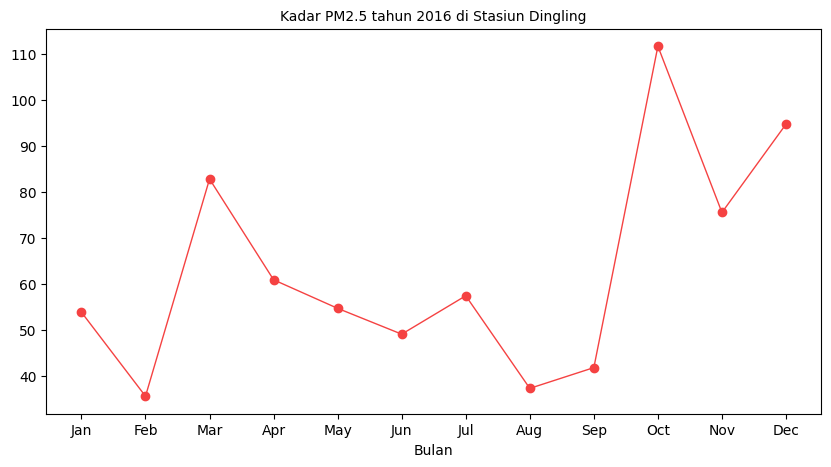

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(
    air_pol["month"],
    air_pol["PM2.5"],
    marker = "o",
    linewidth = 1,
    color = "#f54242"
)
plt.title("Kadar PM2.5 tahun 2016 di Stasiun Dingling", loc="center", fontsize=10)
plt.xticks(fontsize=10)
plt.xticks(range(1,13), months)
plt.yticks(fontsize=10)
plt.xlabel("Bulan", fontsize=10)
plt.show()

### Pertanyaan 2: Bagaimana tren kadar PM10 pada tahun 2016 di Stasiun Dingling?

Penjelasan tahapan:
- Dibuat diagram garis kadar PM10 tahun 2016 setiap bulannya.

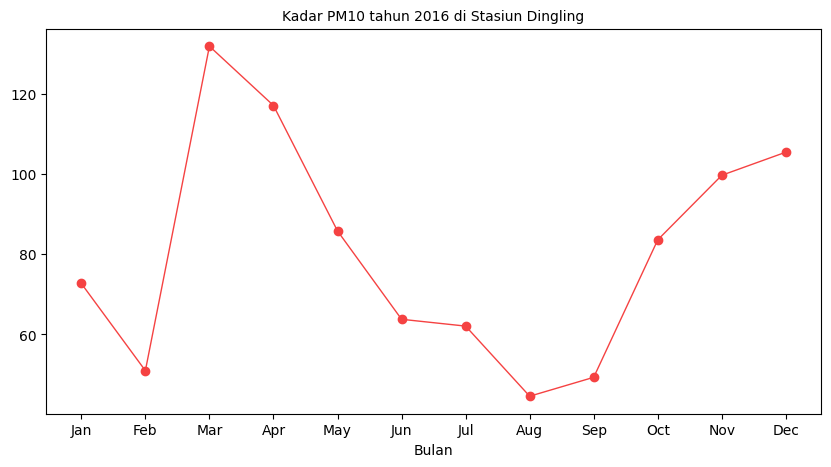

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(
    air_pol["month"],
    air_pol["PM10"],
    marker="o",
    linewidth=1,
    color="#f54242"
)
plt.title("Kadar PM10 tahun 2016 di Stasiun Dingling", loc="center", fontsize=10)
plt.xticks(fontsize=10)
plt.xticks(range(1,13), months)
plt.yticks(fontsize=10)
plt.xlabel("Bulan", fontsize=10)
plt.show()

### Pertanyaan 3: Bagaimana tren kualitas udara mencakup suhu dan tekanan angin pada tahun 2016 di Stasiun Dingling?

Penjelasan tahapan:
- Dibuat dua diagram garis parameter TEMP dan PRES tahun 2016 setiap bulannya dengan objek ax dan dua kolom.

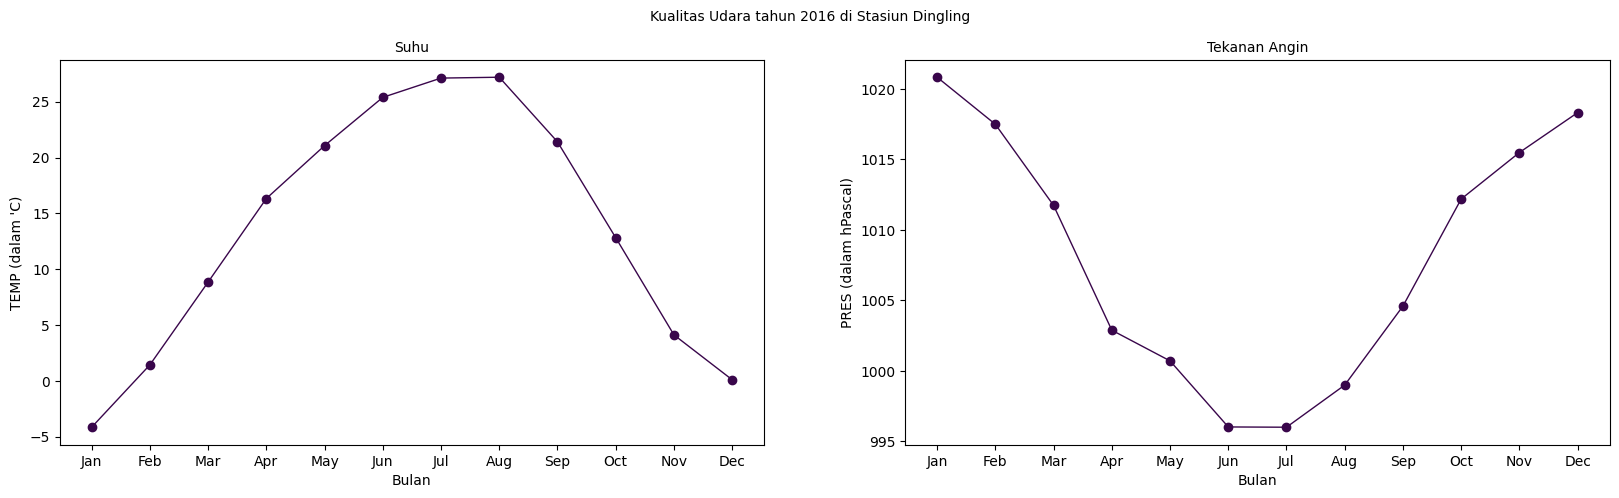

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,5))

ax[0].plot(
    air_par["month"],
    air_par["TEMP"],
    marker="o",
    linewidth=1,
    color="#39064B"
    )
ax[0].tick_params(axis="x", labelsize=10)
ax[0].tick_params(axis="y", labelsize=10)
ax[0].set_xlabel("Bulan", fontsize=10)
ax[0].set_xticks(range(1,13), months)
ax[0].set_ylabel("TEMP (dalam 'C)", fontsize=10)
ax[0].set_title("Suhu", fontsize=10)

ax[1].plot(
    air_par["month"],
    air_par["PRES"],
    marker="o",
    linewidth=1,
    color="#39064B"
    )
ax[1].tick_params(axis="x", labelsize=10)
ax[1].tick_params(axis="y", labelsize=10)
ax[1].set_xlabel("Bulan", fontsize=10)
ax[1].set_xticks(range(1,13), months)
ax[1].set_ylabel("PRES (dalam hPascal)", fontsize=10)
ax[1].set_title("Tekanan Angin", fontsize=10)

plt.suptitle("Kualitas Udara tahun 2016 di Stasiun Dingling", fontsize=10)
plt.show()

### Pertanyaan 4: Bagaimana tren kualitas udara mencakup titik embun, curah hujan, dan kecepatan angin pada tahun 2016 di Stasiun Dingling?

Penjelasan tahapan:
- Dibuat tiga diagram garis parameter DEWP, RAIN, dan WSPM tahun 2016 setiap bulannya dengan objek ax dan tiga kolom.

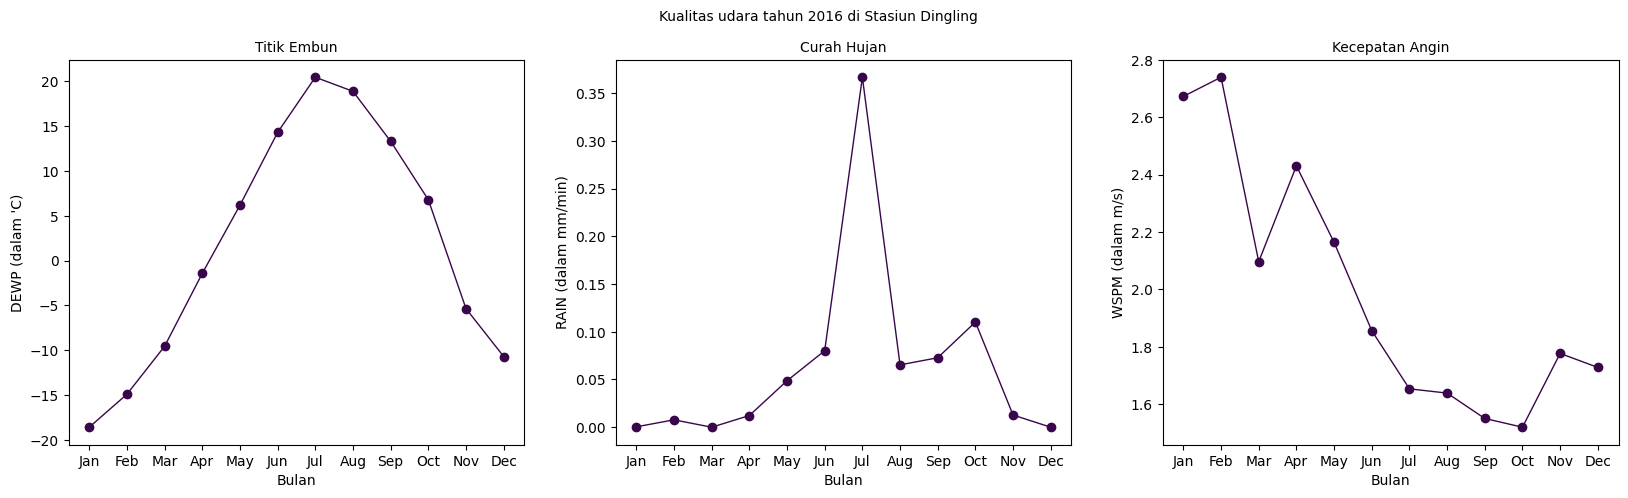

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5))

ax[0].plot(
    wind["month"],
    wind["DEWP"],
    marker="o",
    linewidth=1,
    color="#39064B"
    )
ax[0].tick_params(axis="x", labelsize=10)
ax[0].tick_params(axis="y", labelsize=10)
ax[0].set_xlabel("Bulan", fontsize=10)
ax[0].set_xticks(range(1,13), months)
ax[0].set_ylabel("DEWP (dalam 'C)", fontsize=10)
ax[0].set_title("Titik Embun", fontsize=10)

ax[1].plot(
    wind["month"],
    wind["RAIN"],
    marker="o",
    linewidth=1,
    color="#39064B"
    )
ax[1].tick_params(axis="x", labelsize=10)
ax[1].tick_params(axis="y", labelsize=10)
ax[1].set_xlabel("Bulan", fontsize=10)
ax[1].set_xticks(range(1,13), months)
ax[1].set_ylabel("RAIN (dalam mm/min)", fontsize=10)
ax[1].set_title("Curah Hujan", fontsize=10)

ax[2].plot(
    wind["month"],
    wind["WSPM"],
    marker="o",
    linewidth=1,
    color="#39064B"
    )
ax[2].tick_params(axis="x", labelsize=10)
ax[2].tick_params(axis="y", labelsize=10)
ax[2].set_xlabel("Bulan", fontsize=10)
ax[2].set_xticks(range(1,13), months)
ax[2].set_ylabel("WSPM (dalam m/s)", fontsize=10)
ax[2].set_title("Kecepatan Angin", fontsize=10)

plt.suptitle("Kualitas udara tahun 2016 di Stasiun Dingling", fontsize=10)
plt.show()

### Pertanyaan 5: Bagaimana distribusi arah mata angin pada 2016 di Stasiun Dingling?

Penjelasan tahapan:
- Dibuat diagram batang frekuensi arah mata angin terbanyak di tahun 2016.

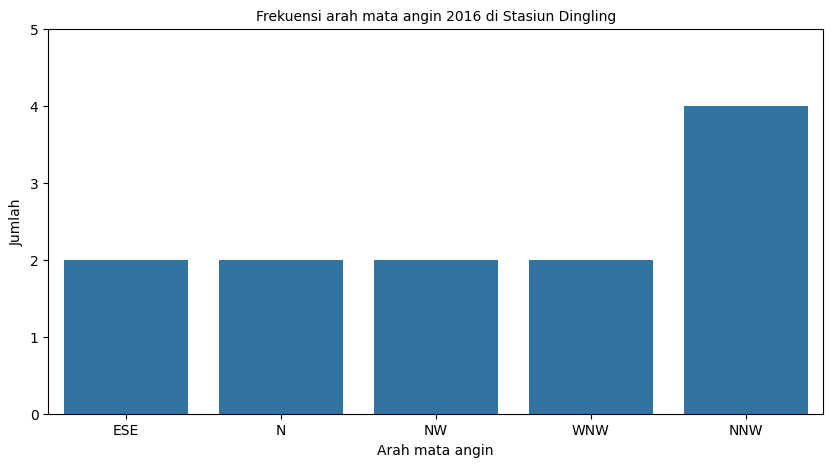

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    y="jumlah",
    x="wind_direction",
    data=winddir_freq.sort_values(by="jumlah", ascending=True)
)

plt.title("Frekuensi arah mata angin 2016 di Stasiun Dingling", fontsize=10)
plt.ylabel("Jumlah", fontsize=10)
plt.yticks(range(0,6))
plt.xlabel("Arah mata angin", fontsize=10)
plt.show()


### Pertanyaan 6: Bagaimana status kualitas udara pada tahun 2016 di Stasiun Dingling berdasarkan PM2.5 dan PM10 di setiap bulannya?

Penjelasan tahapan:
- Dibuat kategorisasi dengan cutoff beberapa poin di arrray bins beserta jenisnya untuk parameter PM2.5 dan PM10.

In [ ]:
bins = [0, 15.5, 55.4, 150.4, 250.4, 500]
cat = ["Baik", "Sedang", "Tidak sehat", "Sangat tidak sehat", "Berbahaya"]
air_pol["Kategori PM2.5"] = pd.cut(air_pol["PM2.5"], bins=bins, labels=cat, include_lowest=True)
print(air_pol)

    year  month       PM2.5        PM10 Kategori PM2.5
34  2016      1   53.833333   72.701613         Sedang
35  2016      2   35.554598   50.981322         Sedang
36  2016      3   82.810484  131.787634    Tidak sehat
37  2016      4   60.886111  117.018056    Tidak sehat
38  2016      5   54.673387   85.774194         Sedang
39  2016      6   49.056944   63.779167         Sedang
40  2016      7   57.411290   62.083333    Tidak sehat
41  2016      8   37.262097   44.619624         Sedang
42  2016      9   41.779167   49.331944         Sedang
43  2016     10  111.706989   83.571237    Tidak sehat
44  2016     11   75.534722   99.651389    Tidak sehat
45  2016     12   94.748656  105.403226    Tidak sehat


In [ ]:
bins = [0, 50, 150, 350, 420, 1000]
cat = ["Baik", "Sedang", "Tidak sehat", "Sangat tidak sehat", "Berbahaya"]
air_pol["Kategori PM10"] = pd.cut(air_pol["PM10"], bins=bins, labels=cat, include_lowest=True)
print(air_pol)

    year  month       PM2.5        PM10 Kategori PM2.5 Kategori PM10
34  2016      1   53.833333   72.701613         Sedang        Sedang
35  2016      2   35.554598   50.981322         Sedang        Sedang
36  2016      3   82.810484  131.787634    Tidak sehat        Sedang
37  2016      4   60.886111  117.018056    Tidak sehat        Sedang
38  2016      5   54.673387   85.774194         Sedang        Sedang
39  2016      6   49.056944   63.779167         Sedang        Sedang
40  2016      7   57.411290   62.083333    Tidak sehat        Sedang
41  2016      8   37.262097   44.619624         Sedang          Baik
42  2016      9   41.779167   49.331944         Sedang          Baik
43  2016     10  111.706989   83.571237    Tidak sehat        Sedang
44  2016     11   75.534722   99.651389    Tidak sehat        Sedang
45  2016     12   94.748656  105.403226    Tidak sehat        Sedang


**Insight:**
- Kualitas udara pada tahun 2016 di Stasiun Dingling menurut kadar PM2.5 dan PM10 sebagian besar sedang.
- Curah hujan pada tahun 2016 di Stasiun Dingling sempat mencapai puncak yang cukup tinggi dengan nilai lebih dari 0.35 mm/min di bulan Juli.


## Analisis Lanjutan (Opsional)

Penjelasan tahapan:
- Dibuat korelasi antara setiap polutan dengan metode korelasi Pearson.

Tujuan analisis:
- Melihat paramater numerik antara dua polutan menggunakan metode koefisien korelasi Pearson.
- Tujuan metode ini adalah menilai linearitas antara dua variabel beserta hubungan perbandingannya dan kekuatannya.
- Nilai positif menandakan hubungan berbanding lurus, sementara nilai negatif menandakan hubungan berbanding terbalik.
- Koefisien korelasi (r) <0,3 menunjukkan korelasi lemah, 0,3-0,6 menunjukkan korelasi sedang, dan >0,6 menunjukkan korelasi kuat.

In [ ]:
corr_df = ding_df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES']].copy()
corr_df = corr_df.corr(method="pearson")
corr_df


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES
PM2.5,1.000000,0.842043,0.460398,0.702151,0.761744,-0.085283,-0.084131,-0.006402
PM10,0.842043,1.000000,0.449780,0.649232,0.668178,-0.024457,-0.053688,-0.040257
SO2,0.460398,0.449780,1.000000,0.614795,0.519160,-0.179352,-0.316167,0.247242
NO2,0.702151,0.649232,0.614795,1.000000,0.777644,-0.317865,-0.308392,0.195648
CO,0.761744,0.668178,0.519160,0.777644,1.000000,-0.263574,-0.280356,0.179288
O3,-0.085283,-0.024457,-0.179352,-0.317865,-0.263574,1.000000,0.536616,-0.423199
TEMP,-0.084131,-0.053688,-0.316167,-0.308392,-0.280356,0.536616,1.000000,-0.837878
PRES,-0.006402,-0.040257,0.247242,0.195648,0.179288,-0.423199,-0.837878,1.000000


Penjelasan tahapan:
- Dibuat heatmap antara setiap polutan berdasarkan korelasi Pearson sebelumnya.

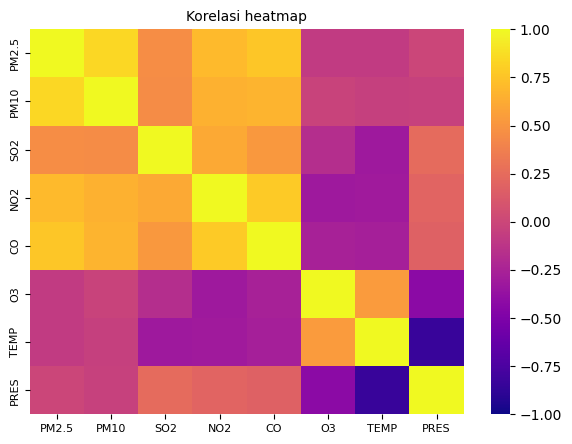

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_df, vmax = 1, vmin = -1, center = 0, cmap='plasma')
ax.tick_params(labelsize = 8)
ax.set_title("Korelasi heatmap", loc="center", fontsize=10)

plt.show()

## Conclusion

- Kualitas udara tahun 2016 di Stasiun Dingling menunjukkan sebagian besar sedang di beberapa bulan.
- Suhu dan Tekanan angin tahun 2016 di Stasiun Dingling rata-rata adalah 13,47'C dan 1007,9 hPa.
- Kualitas udara berdasarkan titik embun, curah hujan, dan kecepatan angin tahun 2016 di Stasiun Dingling rata-rata adalah 1.60'C , 0.06 mm/min, dan 0.98 m/s.
- Arah mata angin terbanyak di tahun 2016 di Stasiun Dingling paling banyak mengarah ke NNW atau ke utara-barat laut.
- Hubungan antara suhu dengan tekanan angin di tahun 2016 di stasiun Dingling yaitu berkorelasi negatif dan di bawah 0,30. Artinya semakin tinggi suhu, semakin rendah tekanan anginnya, dan juga korelasi di bawah 0,30 menurut metode Pearson adalah korelasi lemah, artinya korelasi berbanding terbalik ini tidak signifikan antara suhu dengan tekanan angin.

In [ ]:
ding_df.to_csv("ding.csv", index=False)